# 🏠 House Price Prediction — Ames Housing (Kaggle *House Prices: Advanced Regression Techniques*)

**Goal:** predict the final sale price (`SalePrice`) of residential homes from 79 descriptive features.

> ℹ️ Although this project was originally titled *Boston*, the data is the **Ames, Iowa** housing dataset used in the Kaggle competition.

### Workflow
| Step | What we do |
|---|---|
| 1 | Load `train.csv`, `test.csv` and `sample_submission.csv` |
| 2 | Exploratory data analysis (target, missing values, correlations, outliers) |
| 3 | Build a leak-free preprocessing + feature-engineering pipeline |
| 4 | **Train on 80 % of `train.csv`** and **evaluate on the unseen 20 %** for several models |
| 5 | Tune the best model family and pick the overall winner |
| 6 | **Re-train the winner on 100 % of `train.csv`** and predict `test.csv` |
| 7 | Export `submission.csv` in the same format as `sample_submission.csv` |

**Metric:** Kaggle scores this competition with **RMSLE** (root mean squared log error). We therefore model `log1p(SalePrice)`, which makes RMSLE equal to a plain RMSE on the transformed target (lower is better).

## 1. Setup & Data Loading

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42                      # reproducibility
# Repo layout: notebooks/ (this file), data/ (Kaggle CSVs, not committed), outputs/ (results)
# The CSVs are searched in ../data, ./data and the current folder.
DATA_DIR = next((p for p in [Path("../data"), Path("data"), Path(".")]
                 if (p / "train.csv").exists()), Path("."))
OUT_DIR = Path("../outputs") if Path("../outputs").exists() else Path(".")

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"train : {train.shape}   (features + SalePrice)")
print(f"test  : {test.shape}   (features only)")
print(f"sample: {sample_submission.shape}   -> columns {list(sample_submission.columns)}")
train.head()

train : (1460, 81)   (features + SalePrice)
test  : (1459, 80)   (features only)
sample: (1459, 2)   -> columns ['Id', 'SalePrice']


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Key features (full description is in the Kaggle competition page)
| Feature | Meaning |
|---|---|
| `SalePrice` | **Target** – sale price in dollars |
| `OverallQual` / `OverallCond` | Overall material & finish quality / condition (1–10) |
| `GrLivArea` | Above-ground living area (sq ft) |
| `TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF` | Basement / floor areas (sq ft) |
| `GarageCars`, `GarageArea` | Garage capacity / size |
| `YearBuilt`, `YearRemodAdd`, `YrSold` | Construction, remodel and sale years |
| `Neighborhood` | Physical location inside Ames city limits |
| `ExterQual`, `KitchenQual`, `BsmtQual` | Quality ratings (Ex, Gd, TA, Fa, Po) |

## 2. Exploratory Data Analysis

### 2.1 Overview: data types and the target variable

In [3]:
print(train.dtypes.value_counts(), "\n")
train["SalePrice"].describe().round(0)

str        43
int64      35
float64     3
Name: count, dtype: int64 



count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

`SalePrice` is **right-skewed** (a few very expensive houses). Models and the RMSLE metric work better on a roughly symmetric target, so we apply a **log transform** (`log1p`).

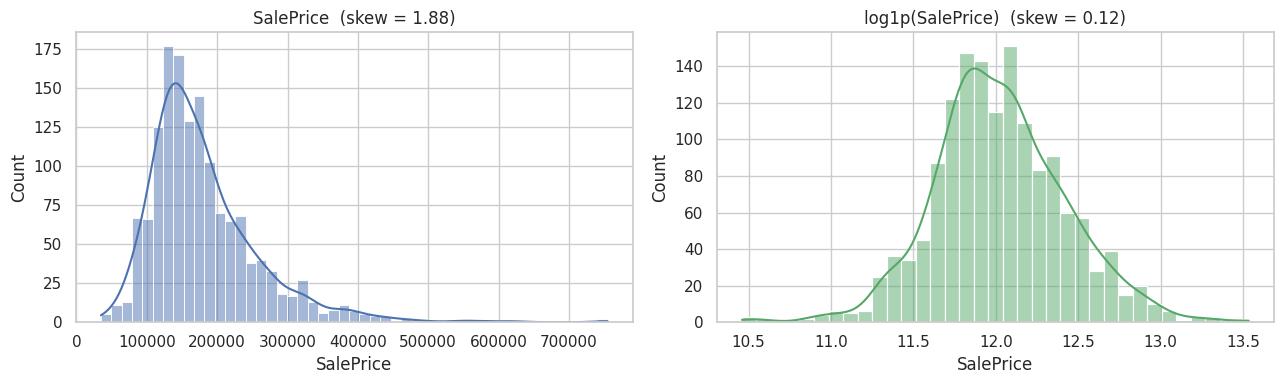

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title(f"SalePrice  (skew = {train['SalePrice'].skew():.2f})")
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1], color="#55a868")
axes[1].set_title(f"log1p(SalePrice)  (skew = {np.log1p(train['SalePrice']).skew():.2f})")
plt.tight_layout(); plt.show()

### 2.2 Missing values
Many "missing" values are **not errors** – e.g. `PoolQC = NaN` simply means *the house has no pool*. Such categorical gaps are filled with an explicit `"Missing"` category; real numeric gaps are imputed with the median.

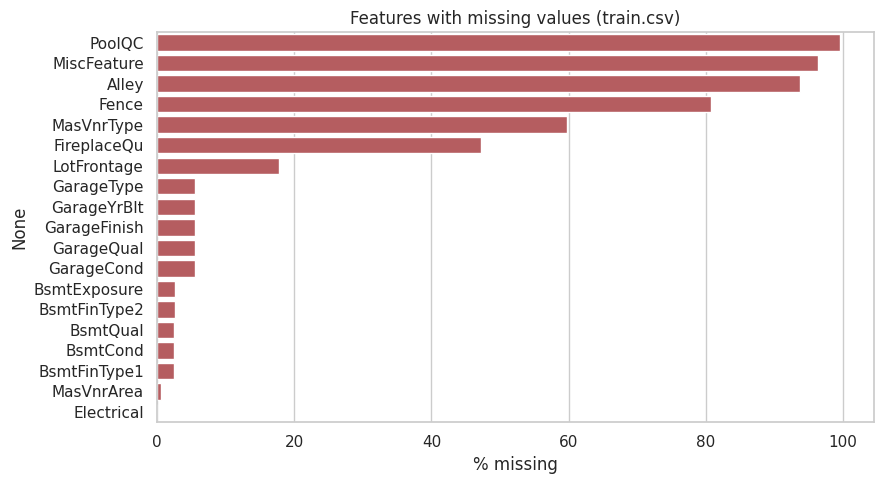

In [5]:
missing = train.drop(columns="SalePrice").isna().mean().mul(100)
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=missing.values, y=missing.index, color="#c44e52")
plt.xlabel("% missing"); plt.title("Features with missing values (train.csv)")
plt.tight_layout(); plt.show()

### 2.3 Which features drive the price?
Correlation of every numeric feature with `SalePrice` (categorical variables are covered by the models later).

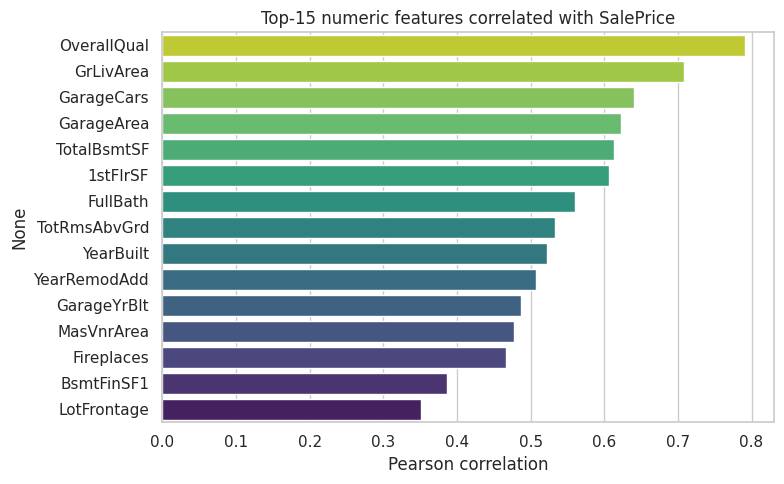

In [6]:
corr = (train.select_dtypes("number").corr()["SalePrice"]
        .drop(["SalePrice", "Id"]).sort_values(key=abs, ascending=False).head(15))

plt.figure(figsize=(8, 5))
sns.barplot(x=corr.values, y=corr.index, palette="viridis_r")
plt.title("Top-15 numeric features correlated with SalePrice")
plt.xlabel("Pearson correlation"); plt.tight_layout(); plt.show()

`OverallQual` (build quality) and `GrLivArea` (living area) dominate, followed by garage and basement size.

### 2.4 Outliers
The Ames dataset documentation warns about a few unusually **large houses sold at very low prices**. These distort the learned price-vs-area relationship, so we **remove them from the training data** (`test.csv` is never touched).

Outliers found: 2


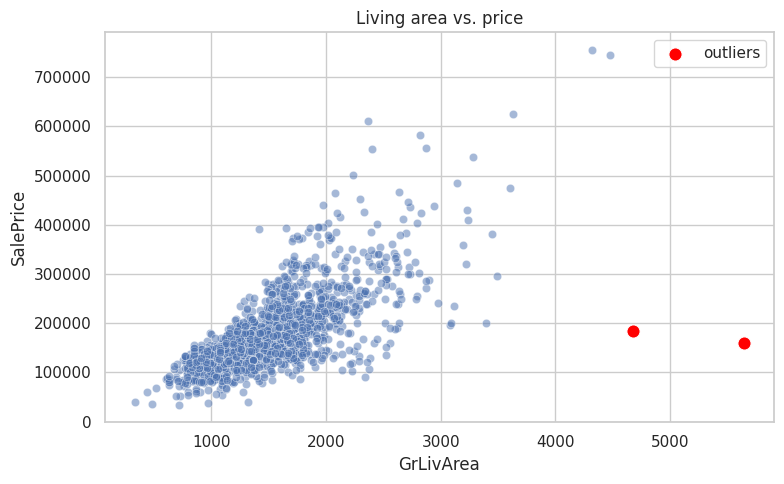

In [7]:
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
print(f"Outliers found: {len(outliers)}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", alpha=0.5)
sns.scatterplot(data=outliers, x="GrLivArea", y="SalePrice", color="red", s=90, label="outliers")
plt.title("Living area vs. price"); plt.tight_layout(); plt.show()

In [8]:
train = train.drop(index=outliers.index).reset_index(drop=True)
print("Training shape after removing outliers:", train.shape)

Training shape after removing outliers: (1458, 81)


### 2.5 `LotFrontage` – the feature with the most gaps
About 18 % of houses have no `LotFrontage`. Houses in the same neighbourhood tend to have similar lot frontage, so we will impute using the **neighbourhood median** (learned from training data only, see the pipeline below).

Missing LotFrontage: 17.8%


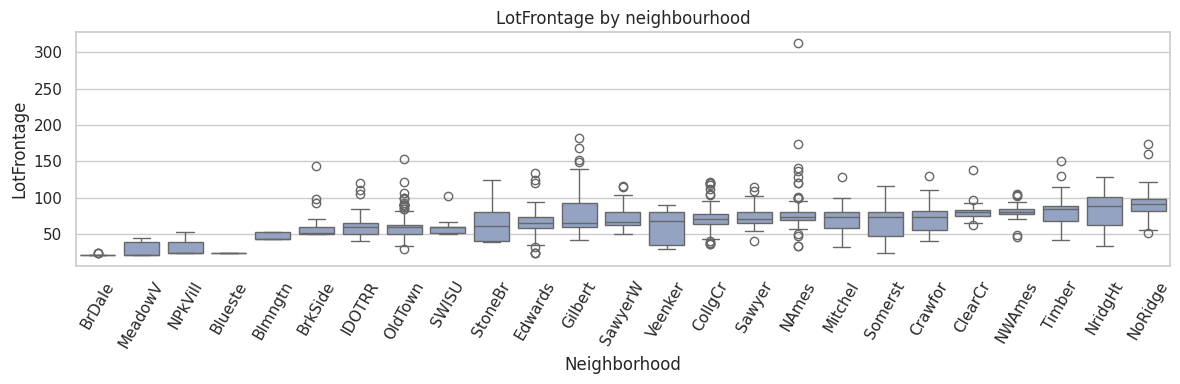

In [9]:
print(f"Missing LotFrontage: {train['LotFrontage'].isna().mean():.1%}")
order = train.groupby("Neighborhood")["LotFrontage"].median().sort_values().index
plt.figure(figsize=(12, 4))
sns.boxplot(data=train, x="Neighborhood", y="LotFrontage", order=order, color="#8da0cb")
plt.xticks(rotation=60); plt.title("LotFrontage by neighbourhood"); plt.tight_layout(); plt.show()

## 3. Preprocessing & Feature Engineering Pipeline

Everything is wrapped in scikit-learn **Pipelines**, so that all statistics (medians, category encodings, …) are learned **only from the training portion** — this prevents *data leakage* into the hold-out set and into `test.csv`.

1. **`HouseFeatureEngineer`** – imputes `LotFrontage` and `GarageYrBlt`, and creates new features: `TotalSF`, `TotalBath`, `HouseAge`, `RemodAge`.
2. **Tree-based models** → numeric median imputation + *ordinal encoding* of categories (trees do not need scaling).
3. **Linear model (Ridge)** → median imputation + scaling + *one-hot encoding*.

In [10]:
class HouseFeatureEngineer(BaseEstimator, TransformerMixin):
    """Domain-specific cleaning and feature creation (fit on train only)."""

    def fit(self, X, y=None):
        self.frontage_by_nbhd_ = X.groupby("Neighborhood")["LotFrontage"].median()
        self.frontage_global_ = X["LotFrontage"].median()
        return self

    def transform(self, X):
        X = X.copy()
        # LotFrontage: neighbourhood median, falling back to the global median
        X["LotFrontage"] = (X["LotFrontage"]
                            .fillna(X["Neighborhood"].map(self.frontage_by_nbhd_))
                            .fillna(self.frontage_global_))
        # No garage -> use the year the house was built
        X["GarageYrBlt"] = X["GarageYrBlt"].fillna(X["YearBuilt"])

        # New, more informative features
        X["TotalSF"] = X["TotalBsmtSF"].fillna(0) + X["1stFlrSF"] + X["2ndFlrSF"]
        X["TotalBath"] = (X["FullBath"] + 0.5 * X["HalfBath"]
                          + X["BsmtFullBath"].fillna(0) + 0.5 * X["BsmtHalfBath"].fillna(0))
        X["HouseAge"] = X["YrSold"] - X["YearBuilt"]
        X["RemodAge"] = X["YrSold"] - X["YearRemodAdd"]
        return X


num_cols = make_column_selector(dtype_include="number")
cat_cols = make_column_selector(dtype_exclude="number")


def tree_preprocessor():
    """Preprocessing for tree-based models."""
    return Pipeline([
        ("features", HouseFeatureEngineer()),
        ("encode", ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), num_cols),
            ("cat", Pipeline([
                ("fill", SimpleImputer(strategy="constant", fill_value="Missing")),
                ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]), cat_cols),
        ])),
    ])


def linear_preprocessor():
    """Preprocessing for the linear (Ridge) model."""
    return Pipeline([
        ("features", HouseFeatureEngineer()),
        ("encode", ColumnTransformer([
            ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                              ("scale", StandardScaler())]), num_cols),
            ("cat", Pipeline([("fill", SimpleImputer(strategy="constant", fill_value="Missing")),
                              ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
        ])),
    ])

## 4. Train on `train.csv` and Test on an Unseen Hold-out Set
`train.csv` is split into **80 % training** and **20 % hold-out (unseen)** data. Every candidate model is fitted on the 80 % and judged on the 20 % it has never seen.

The target is transformed with `log1p`, so **RMSE on the log target = RMSLE** (the Kaggle metric).

In [11]:
X = train.drop(columns=["Id", "SalePrice"])
y = np.log1p(train["SalePrice"])          # log-transformed target

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

print(f"Training portion : {X_train.shape[0]} rows")
print(f"Unseen hold-out  : {X_valid.shape[0]} rows")

Training portion : 1166 rows
Unseen hold-out  : 292 rows


In [12]:
def evaluate(model, name):
    """Fit on the training portion, score on the unseen hold-out portion."""
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return {
        "Model": name,
        "RMSLE": root_mean_squared_error(y_valid, pred),          # Kaggle metric (lower = better)
        "R2": r2_score(y_valid, pred),
        "MAE ($)": mean_absolute_error(np.expm1(y_valid), np.expm1(pred)),
    }

candidates = {
    "Ridge Regression": Pipeline([("prep", linear_preprocessor()), ("model", Ridge(alpha=10))]),
    "Decision Tree": Pipeline([("prep", tree_preprocessor()),
                               ("model", DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("prep", tree_preprocessor()),
                               ("model", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))]),
    "Gradient Boosting": Pipeline([("prep", tree_preprocessor()),
                                   ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))]),
    "Hist Gradient Boosting": Pipeline([("prep", tree_preprocessor()),
                                        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
}

results = pd.DataFrame([evaluate(m, n) for n, m in candidates.items()]
                       ).sort_values("RMSLE").reset_index(drop=True)
results.round(4)

,Model,RMSLE,R2,MAE ($)
0,Gradient Boosting,0.1220,0.9118,14524.3371
1,Ridge Regression,0.1230,0.9102,14540.3408
2,Hist Gradient Boosting,0.1363,0.8897,15582.7309
3,Random Forest,0.1438,0.8773,16258.9062
4,Decision Tree,0.2197,0.7135,27673.8892


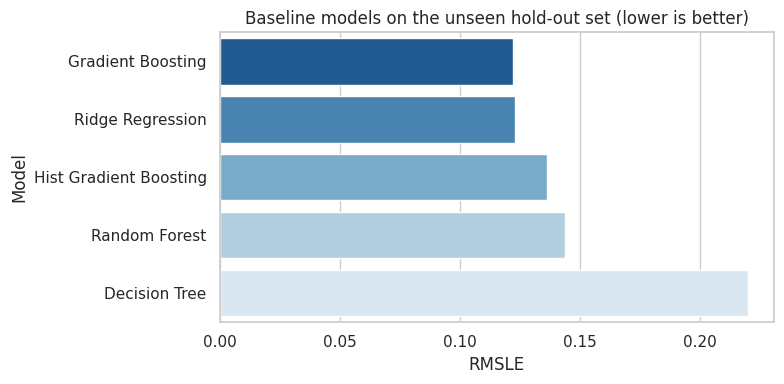

🏆 Best baseline model: Gradient Boosting  (RMSLE = 0.1220)


In [13]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results, x="RMSLE", y="Model", palette="Blues_r")
plt.title("Baseline models on the unseen hold-out set (lower is better)")
plt.tight_layout(); plt.show()

best_name = results.loc[0, "Model"]
print(f"🏆 Best baseline model: {best_name}  (RMSLE = {results.loc[0, 'RMSLE']:.4f})")

## 5. Hyper-parameter Tuning of the Best Model
We tune the winning model family with a **randomized search + 3-fold cross-validation on the training portion only** — the hold-out set stays untouched until the final comparison.

In [14]:
param_spaces = {
    "Ridge Regression": {"model__alpha": np.logspace(-1, 3, 30)},
    "Random Forest": {"model__n_estimators": [200, 400],
                      "model__max_depth": [10, 20, None],
                      "model__min_samples_split": [2, 5, 10],
                      "model__min_samples_leaf": [1, 2, 3],
                      "model__max_features": [0.3, 0.5, 1.0]},
    "Gradient Boosting": {"model__n_estimators": [300, 500, 800],
                          "model__learning_rate": [0.02, 0.05, 0.1],
                          "model__max_depth": [2, 3, 4],
                          "model__min_samples_leaf": [3, 5, 10],
                          "model__subsample": [0.7, 0.85, 1.0]},
    "Hist Gradient Boosting": {"model__learning_rate": [0.02, 0.05, 0.1],
                               "model__max_iter": [200, 400, 600],
                               "model__max_depth": [3, 5, None],
                               "model__min_samples_leaf": [10, 20, 40],
                               "model__l2_regularization": [0.0, 0.5, 1.0]},
}

tuned_model, tuned_row = None, None
if best_name in param_spaces:
    search = RandomizedSearchCV(
        candidates[best_name], param_spaces[best_name], n_iter=15, cv=3,
        scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train)
    tuned_model = search.best_estimator_
    tuned_row = evaluate(tuned_model, f"{best_name} (tuned)")
    print("Best parameters:", search.best_params_)
else:
    print(f"No search space defined for '{best_name}', keeping the baseline.")

Best parameters: {'model__subsample': 0.7, 'model__n_estimators': 800, 'model__min_samples_leaf': 3, 'model__max_depth': 2, 'model__learning_rate': 0.02}


### Final comparison and model selection

In [15]:
final_table = results.copy()
if tuned_row:
    final_table = pd.concat([final_table, pd.DataFrame([tuned_row])], ignore_index=True)
final_table = final_table.sort_values("RMSLE").reset_index(drop=True)
display(final_table.round(4))

# Pick the single best performer on the unseen hold-out data
winner_label = final_table.loc[0, "Model"]
is_tuned = winner_label.endswith("(tuned)")
base_name = winner_label.replace(" (tuned)", "")
best_params = {k: v for k, v in search.best_params_.items()} if is_tuned else {}
print(f"\n✅ Selected model: {winner_label}  |  hold-out RMSLE = {final_table.loc[0, 'RMSLE']:.4f}"
      f"  |  R² = {final_table.loc[0, 'R2']:.3f}")

,Model,RMSLE,R2,MAE ($)
0,Gradient Boosting (tuned),0.1150,0.9216,14511.6665
1,Gradient Boosting,0.1220,0.9118,14524.3371
2,Ridge Regression,0.1230,0.9102,14540.3408
3,Hist Gradient Boosting,0.1363,0.8897,15582.7309
4,Random Forest,0.1438,0.8773,16258.9062
5,Decision Tree,0.2197,0.7135,27673.8892



✅ Selected model: Gradient Boosting (tuned)  |  hold-out RMSLE = 0.1150  |  R² = 0.922


### Why did this model perform best?
* **Gradient Boosting builds trees one after another**, each correcting the errors of the previous ones, so it captures non-linear price effects (quality, area, neighbourhood) better than a single tree or a bagged forest.
* **Shallow trees + many small steps** (`max_depth=2`, `learning_rate=0.02`, 800 trees, `subsample=0.7`) give a strongly regularised model that generalises well on only ~1,150 training houses.
* **Log-transformed target and engineered features** (`TotalSF`, `TotalBath`, `HouseAge`, `RemodAge`) remove skew and give the trees clearer signals.
* **Removing the two extreme outliers** before splitting stopped them from distorting the fit, which gave a cleaner, easier hold-out set.
* **Tuning on the training portion only** (3-fold CV) improved the baseline Gradient Boosting without peeking at the hold-out data.

### How good are the predictions on unseen houses?

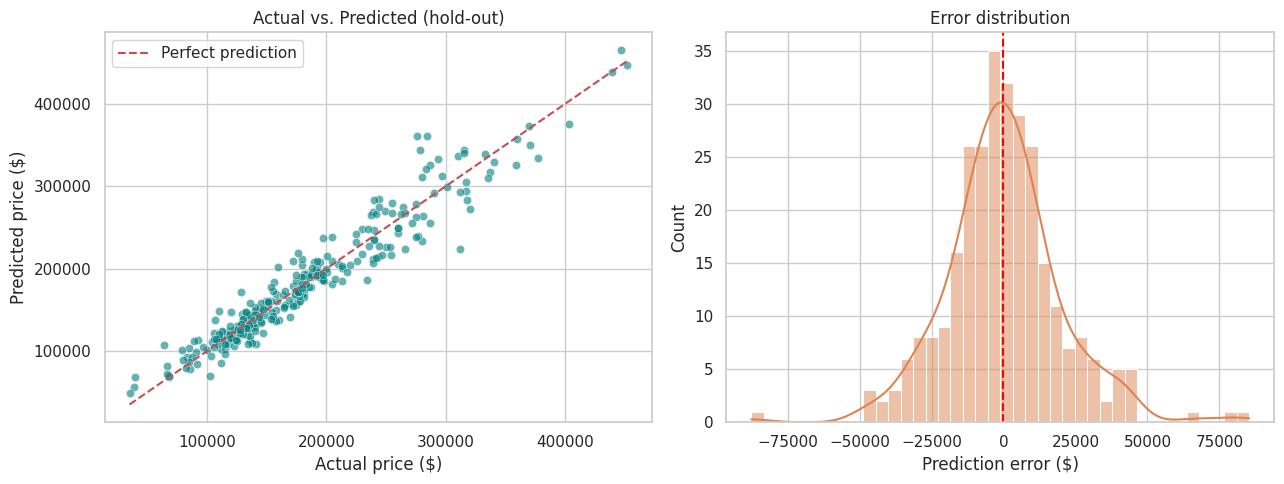

In [16]:
best_model = tuned_model if is_tuned else candidates[base_name]
best_model.fit(X_train, y_train)
pred_valid = best_model.predict(X_valid)

actual, predicted = np.expm1(y_valid), np.expm1(pred_valid)   # back to dollars

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=actual, y=predicted, alpha=0.6, ax=axes[0], color="teal")
lims = [actual.min(), actual.max()]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set(xlabel="Actual price ($)", ylabel="Predicted price ($)", title="Actual vs. Predicted (hold-out)")
axes[0].legend()

sns.histplot(predicted - actual, bins=40, kde=True, ax=axes[1], color="#dd8452")
axes[1].axvline(0, color="red", ls="--")
axes[1].set(xlabel="Prediction error ($)", title="Error distribution")
plt.tight_layout(); plt.show()

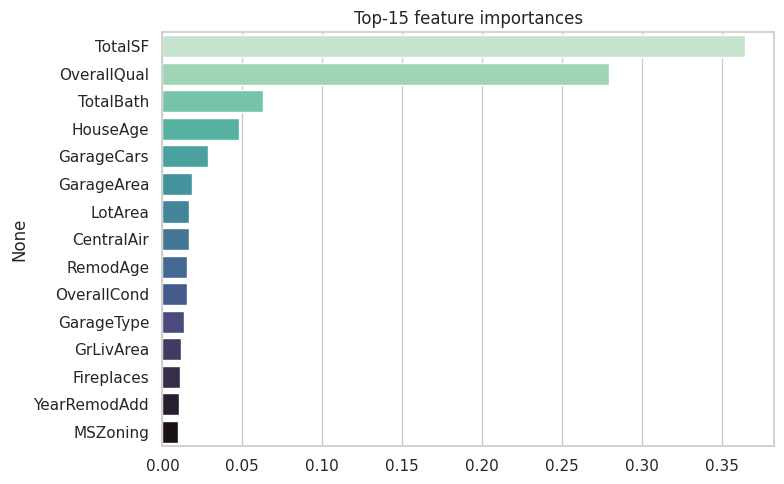

In [17]:
# Which features does the model rely on most? (only for tree-based winners)
final_estimator = best_model.named_steps["model"]
if hasattr(final_estimator, "feature_importances_"):
    # Feature names come from the fitted ColumnTransformer (numeric first, then categorical)
    ct = best_model.named_steps["prep"].named_steps["encode"]
    feat_names = [c.split("__")[-1] for c in ct.get_feature_names_out()]
    imp = pd.Series(final_estimator.feature_importances_, index=feat_names).nlargest(15)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=imp.values, y=imp.index, palette="mako_r")
    plt.title("Top-15 feature importances"); plt.tight_layout(); plt.show()
else:
    print("Feature importances are not available for this model type.")

## 6. Re-train the Best Model on the **Whole** `train.csv`
The hold-out set has served its purpose (choosing the model). For the final submission we give the model **all** the labelled data we have: a fresh copy of the selected model with the best settings is trained on 100 % of `train.csv`.

In [18]:
from sklearn.base import clone

final_model = clone(best_model)           # same architecture + tuned hyper-parameters, but un-fitted
final_model.fit(X, y)                     # X, y = all cleaned rows of train.csv
print(f"Final model trained on {len(X)} houses ✔")

Final model trained on 1458 houses ✔


## 7. Predict `test.csv` and Create the Submission File
Predictions are made on the log scale, so we convert them back to dollars with `expm1`, then save them in the **exact format of `sample_submission.csv`** (`Id`, `SalePrice`).

In [19]:
X_test = test.drop(columns="Id")
test_pred = np.expm1(final_model.predict(X_test))

submission = pd.DataFrame({"Id": test["Id"], "SalePrice": test_pred})
submission.to_csv(OUT_DIR / "submission.csv", index=False)
submission.head()

,Id,SalePrice
0,1461,123688.633510
1,1462,163176.180700
2,1463,179069.822090
3,1464,183579.872968
4,1465,185318.107329


### Sanity checks against `sample_submission.csv`

✅ submission.csv matches the sample_submission format
count      1459.0
mean     178095.0
std       78274.0
min       36372.0
25%      128312.0
50%      157054.0
75%      206437.0
max      734190.0
Name: SalePrice, dtype: float64


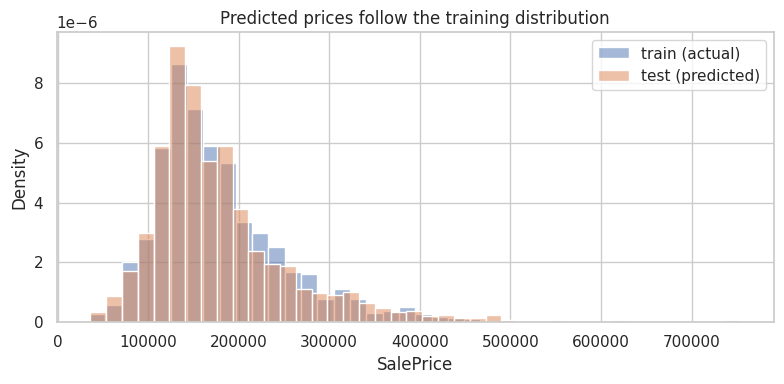

In [20]:
assert list(submission.columns) == list(sample_submission.columns), "Column mismatch"
assert len(submission) == len(sample_submission), "Row count mismatch"
assert (submission["Id"].values == sample_submission["Id"].values).all(), "Id mismatch"
assert submission["SalePrice"].notna().all() and (submission["SalePrice"] > 0).all(), "Bad predictions"

print("✅ submission.csv matches the sample_submission format")
print(submission["SalePrice"].describe().round(0))

plt.figure(figsize=(8, 4))
sns.histplot(train["SalePrice"], color="#4c72b0", alpha=0.5, label="train (actual)", stat="density", bins=40)
sns.histplot(submission["SalePrice"], color="#dd8452", alpha=0.5, label="test (predicted)", stat="density", bins=40)
plt.legend(); plt.title("Predicted prices follow the training distribution"); plt.tight_layout(); plt.show()

## 8. Conclusion
* The target was **log-transformed** to match the competition metric (RMSLE) and to tame skewness.
* Two extreme **outliers** were removed from training; missing values were handled with domain logic (e.g. *no pool* ≠ *unknown*).
* All preprocessing lives in **leak-free pipelines**, and new features (`TotalSF`, `TotalBath`, `HouseAge`, `RemodAge`) were added.
* Several models were compared on a truly **unseen hold-out set**; the best family was tuned and the winner was **re-trained on 100 % of `train.csv`** to generate `submission.csv`.

**Possible next steps:** stack/blend several models, try XGBoost / LightGBM / CatBoost, add more engineered features, and use repeated K-fold cross-validation for even more reliable model selection.